In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense,Input,Flatten,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time

In [4]:
HIDDEN_LAYERS = [1,2,3]
NEURONS = [64,128,256]
ACTIVATION = 'relu'
OPTIMIZERS = Adam
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 10
DROPOUT_PROB = [0,0.3]

In [5]:
(x_train_full,y_train_full),(x_test,y_test) = fashion_mnist.load_data()

In [6]:
x_train,x_val,y_train,y_val = train_test_split(x_train_full,y_train_full,test_size=0.2,random_state=42,stratify=y_train_full)

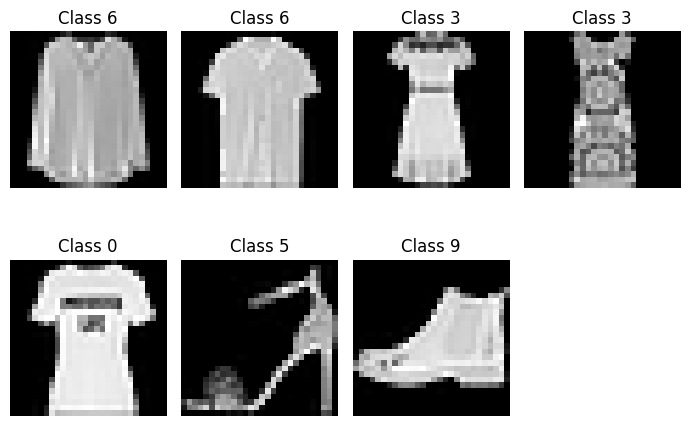

In [7]:
plt.figure(figsize=(7,7))
for i in range(7):
    plt.subplot(3,4,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.axis("off")
    plt.title(f"Class {y_train[i]}")
    plt.tight_layout()

plt.show()

In [8]:
len(x_train)

48000

In [9]:
x_train_norm = x_train.astype("float32")/255.0
x_test_norm = x_test.astype("float32")/255.0
x_val_norm = x_val.astype("float32")/255.0

In [10]:
y_train = to_categorical(y_train,num_classes=10)
y_test = to_categorical(y_test,num_classes=10)
y_val = to_categorical(y_val,num_classes=10)

In [11]:
def build_and_train_model(x,y,HIDDEN_LAYERS,NEURONS,ACTIVATION,OPTIMIZER,LEARNING_RATE,BATCH_SIZE,EPOCHS,DROPOUT_PROB,VALIDATION_DATA):
    model = Sequential([Input(shape=(28,28))])
    model.add(Flatten())
    for i in range(HIDDEN_LAYERS):
        model.add(Dense(NEURONS,activation=ACTIVATION))
    if DROPOUT_PROB > 0:
        model.add(Dropout(DROPOUT_PROB))
    model.add(Dense(10,activation='softmax'))
    model.compile(optimizer=OPTIMIZER(learning_rate=LEARNING_RATE),loss='categorical_crossentropy',metrics=['accuracy'])
    history = model.fit(x,y,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=VALIDATION_DATA)
    return model,history

In [12]:
x_train_norm.shape

(48000, 28, 28)

In [13]:
y_train.shape

(48000, 10)

In [14]:
import mlflow
mlflow.set_tracking_uri(uri="http://localhost:5000")

In [15]:
mlflow.set_experiment("MLOps Experiment 2 - Comparing Neural Networks with different Hyperparameters")

2026/08/03 21:48:18 INFO mlflow.tracking.fluent: Experiment with name 'MLOps Experiment 2 - Comparing Neural Networks with different Hyperparameters' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///D:/Workspace/MLOps Exercise/MLflow/Experiment '
 '2/mlruns/810840401775757794'), creation_time=1785773898756, experiment_id='810840401775757794', last_update_time=1785773898756, lifecycle_stage='active', name='MLOps Experiment 2 - Comparing Neural Networks with different Hyperparameters', tags={}>

In [16]:
result = {}
i = 1

In [18]:
for h in HIDDEN_LAYERS:
    for n in NEURONS:
        for drop in DROPOUT_PROB:
            print(f"Training Model {i}/{len(HIDDEN_LAYERS)*len(NEURONS)*len(DROPOUT_PROB)}")
            parameters_results = {}
            start_time = time.time()
            model,history = build_and_train_model(x=x_train_norm,y=y_train,HIDDEN_LAYERS=h,NEURONS=n,ACTIVATION=ACTIVATION,OPTIMIZER=OPTIMIZERS,LEARNING_RATE=LEARNING_RATE,BATCH_SIZE=BATCH_SIZE,EPOCHS=EPOCHS,DROPOUT_PROB=drop,VALIDATION_DATA=(x_val_norm,y_val))
            end_time = time.time()
            test_loss,test_accuracy = model.evaluate(x_test_norm,y_test)
            hyperparameters = {
                'HIDDEN_LAYERS' : h,
                'NEURONS' : n,
                'ACTIVATION' : ACTIVATION,
                'OPTIMIZER' : "Adam",
                'LEARNING_RATE' : LEARNING_RATE,
                'BATCH_SIZE' : BATCH_SIZE,
                'EPOCHS' : EPOCHS,
                'DROPOUT' : drop
            }
            metrics = {
                'TRAINING_ACCURACY' : history.history['accuracy'][-1],
                'TRAINING_LOSS' : history.history['loss'][-1],
                'VAL_ACCURACY' : history.history['val_accuracy'][-1],
                'VAL_LOSS' : history.history['val_loss'][-1],
                'TEST_ACCURACY' : test_accuracy,
                'TEST_LOSS' : test_loss,
                'MODEL_RUN_TIME' : end_time-start_time
            }
            model_name = f"Model {i}"
            with mlflow.start_run(run_name=model_name):
                mlflow.log_params(hyperparameters)
                mlflow.log_metrics(metrics)
                mlflow.tensorflow.log_model(model,model_name)
            result[model_name] = hyperparameters|metrics
            i = i+1
print(f"{len(HIDDEN_LAYERS)*len(NEURONS)*len(DROPOUT_PROB)} Models Trained successfully")

Training Model 1/18
Epoch 1/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.5435 - accuracy: 0.8100 - val_loss: 0.4258 - val_accuracy: 0.8470
Epoch 2/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.4078 - accuracy: 0.8559 - val_loss: 0.3822 - val_accuracy: 0.8652
Epoch 3/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.3669 - accuracy: 0.8676 - val_loss: 0.3721 - val_accuracy: 0.8678
Epoch 4/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.3385 - accuracy: 0.8774 - val_loss: 0.3349 - val_accuracy: 0.8792
Epoch 5/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.3217 - accuracy: 0.8828 - val_loss: 0.3357 - val_accuracy: 0.8791
Epoch 6/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.3074 - accuracy: 0.8856 - val_loss: 0.3330 - val_accuracy: 0.8832
Epoch 7/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.2954 - accuracy: 0.8906 - val_loss:

2026/08/03 21:53:50 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmpw29hu_qr\model\data\model\assets


E:\tf_gpu_venv\py310\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


Training Model 2/18
Epoch 1/10
1500/1500 [==============================] - 7s 4ms/step - loss: 0.6460 - accuracy: 0.7751 - val_loss: 0.4328 - val_accuracy: 0.8431
Epoch 2/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4741 - accuracy: 0.8302 - val_loss: 0.3906 - val_accuracy: 0.8610
Epoch 3/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.4354 - accuracy: 0.8414 - val_loss: 0.3751 - val_accuracy: 0.8659
Epoch 4/10
1500/1500 [==============================] - 10s 7ms/step - loss: 0.4157 - accuracy: 0.8500 - val_loss: 0.3590 - val_accuracy: 0.8714
Epoch 5/10
1500/1500 [==============================] - 11s 7ms/step - loss: 0.4002 - accuracy: 0.8552 - val_loss: 0.3587 - val_accuracy: 0.8715
Epoch 6/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.3857 - accuracy: 0.8600 - val_loss: 0.3438 - val_accuracy: 0.8775
Epoch 7/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.3739 - accuracy: 0.8623 - val_loss: 

...

INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmpof7ws47_\model\data\model\assets
Training Model 17/18
Epoch 1/10
1500/1500 [==============================] - 13s 8ms/step - loss: 0.4968 - accuracy: 0.8190 - val_loss: 0.3976 - val_accuracy: 0.8572
Epoch 2/10
1500/1500 [==============================] - 13s 9ms/step - loss: 0.3731 - accuracy: 0.8637 - val_loss: 0.3882 - val_accuracy: 0.8591
Epoch 3/10
1500/1500 [==============================] - 15s 10ms/step - loss: 0.3346 - accuracy: 0.8761 - val_loss: 0.3520 - val_accuracy: 0.8758
Epoch 4/10
1500/1500 [==============================] - 14s 9ms/step - loss: 0.3126 - accuracy: 0.8827 - val_loss: 0.3403 - val_accuracy: 0.8794
Epoch 5/10
1500/1500 [==============================] - 14s 9ms/step - loss: 0.2908 - accuracy: 0.8908 - val_loss: 0.3180 - val_accuracy: 0.8877
Epoch 6/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.2793 - accuracy: 0.8948 - val_loss: 0.3290 - val_accuracy: 0.8838
Epoc

2026/08/03 22:29:45 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmpkwtbefrl\model\data\model\assets
Training Model 18/18
Epoch 1/10
1500/1500 [==============================] - 14s 9ms/step - loss: 0.5231 - accuracy: 0.8104 - val_loss: 0.3936 - val_accuracy: 0.8559
Epoch 2/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.3882 - accuracy: 0.8584 - val_loss: 0.3528 - val_accuracy: 0.8724
Epoch 3/10
1500/1500 [==============================] - 20s 13ms/step - loss: 0.3497 - accuracy: 0.8704 - val_loss: 0.3460 - val_accuracy: 0.8721
Epoch 4/10
1500/1500 [==============================] - 20s 13ms/step - loss: 0.3251 - accuracy: 0.8780 - val_loss: 0.3273 - val_accuracy: 0.8793
Epoch 5/10
1500/1500 [==============================] - 25s 17ms/step - loss: 0.3021 - accuracy: 0.8874 - val_loss: 0.3132 - val_accuracy: 0.8861
Epoch 6/10
1500/1500 [==============================] - 16s 10ms/step - loss: 0.2895 - accuracy: 0.8923 - val_loss: 0.3652 - val_accuracy: 0.8739
Ep

2026/08/03 22:32:40 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\DELL\AppData\Local\Temp\tmp9t5grv1m\model\data\model\assets
18 Models Trained successfully


In [90]:
result

{'Model 1': {'HIDDEN_LAYERS': 1,
  'NEURONS': 64,
  'ACTIVATION': 'relu',
  'OPTIMIZER': 'Adam',
  'LEARNING_RATE': 0.001,
  'BATCH_SIZE': 32,
  'EPOCHS': 10,
  'DROPOUT': 0,
  'TRAINING_ACCURACY': 0.8989583253860474,
  'TRAINING_LOSS': 0.2687230110168457,
  'VAL_ACCURACY': 0.878083348274231,
  'VAL_LOSS': 0.34274056553840637,
  'TEST_ACCURACY': 0.8633999824523926,
  'TEST_LOSS': 0.38538601994514465,
  'MODEL_RUN_TIME': 108.07191038131714},
 'Model 2': {'HIDDEN_LAYERS': 1,
  'NEURONS': 64,
  'ACTIVATION': 'relu',
  'OPTIMIZER': 'Adam',
  'LEARNING_RATE': 0.001,
  'BATCH_SIZE': 32,
  'EPOCHS': 10,
  'DROPOUT': 0.3,
  'TRAINING_ACCURACY': 0.8709375262260437,
  'TRAINING_LOSS': 0.34730640053749084,
  'VAL_ACCURACY': 0.8838333487510681,
  'VAL_LOSS': 0.32594794034957886,
  'TEST_ACCURACY': 0.870199978351593,
  'TEST_LOSS': 0.36206695437431335,
  'MODEL_RUN_TIME': 106.17381024360657},
 'Model 3': {'HIDDEN_LAYERS': 1,
  'NEURONS': 128,
  'ACTIVATION': 'relu',
  'OPTIMIZER': 'Adam',
  'LEARNI

In [91]:
import pandas as pd
df = pd.DataFrame(result).T
df

,HIDDEN_LAYERS,NEURONS,ACTIVATION,OPTIMIZER,LEARNING_RATE,BATCH_SIZE,EPOCHS,DROPOUT,TRAINING_ACCURACY,TRAINING_LOSS,VAL_ACCURACY,VAL_LOSS,TEST_ACCURACY,TEST_LOSS,MODEL_RUN_TIME
Model 1,1,64,relu,Adam,0.001,32,10,0,0.898958,0.268723,0.878083,0.342741,0.8634,0.385386,108.07191
Model 2,1,64,relu,Adam,0.001,32,10,0.3,0.870938,0.347306,0.883833,0.325948,0.8702,0.362067,106.17381
Model 3,1,128,relu,Adam,0.001,32,10,0,0.908167,0.246491,0.888167,0.321221,0.8764,0.357237,120.781129
Model 4,1,128,relu,Adam,0.001,32,10,0.3,0.885271,0.30911,0.882917,0.319069,0.8733,0.355965,142.768836
Model 5,1,256,relu,Adam,0.001,32,10,0,0.912771,0.231455,0.892333,0.300784,0.8839,0.329467,116.363249
Model 6,1,256,relu,Adam,0.001,32,10,0.3,0.890437,0.292456,0.883083,0.323903,0.869,0.358048,81.638363
Model 7,2,64,relu,Adam,0.001,32,10,0,0.904125,0.256876,0.891667,0.312612,0.881,0.34567,75.858297
Model 8,2,64,relu,Adam,0.001,32,10,0.3,0.892229,0.288572,0.881167,0.324683,0.8677,0.36601,82.662582
Model 9,2,128,relu,Adam,0.001,32,10,0,0.910021,0.237698,0.885417,0.326919,0.8732,0.355082,82.654633
Model 10,2,128,relu,Adam,0.001,32,10,0.3,0.902125,0.261216,0.882917,0.344431,0.8715,0.377507,81.595537


In [92]:
df.to_csv("hyperparameter_results.csv", index=False)